
# TRNG Approach A - RTC vs TCC Jitter on XMEGA (CW303)
Quick testbench to compile, flash, collect, and evaluate random bits from a
TRUERA-style TRNG adapted to the ATxmega128D4 on ChipWhisperer CW303.

> Duplicate this notebook to create Approach B/C/D (e.g., ADC noise, ring oscillators, SRAM startup), changing only the acquisition cell title & acquisition code. Each notebook keeps the same test battery, so you can compare results apples-to-apples.



## Requirements
- ChipWhisperer installed (`pip install chipwhisperer`), hardware connected (CW-Lite/NAE-Scope + CW303 XMEGA target).
- Your TRNG firmware placed in `FW_DIR` (below) and builds with `make PLATFORM=CW303` to create `.hex`.
- The firmware implements SimpleSerial command: `r<N>` -> returns `ceil(N/8)` bytes (MSB-first packing).

If you use my minimal no-FIFO firmware from chat, you're good.


## 1) Build firmware

In [1]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial)
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 1946034                   to 25492664                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

In [53]:
%%bash
make PLATFORM=CWLITEXMEGA SOURCE=temp_sen.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     temp_sen.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/XMEGA_AES_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/uart.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/usart_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/h

## 2) Program target (XMEGA on CW303)

In [54]:
hex = "output-CWLITEXMEGA.hex"
cw.program_target(scope, cw.programmers.XMEGAProgrammer, hex)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4063 bytes


## 3) Acquire random bits - Approach A: RTC vs TCC jitter

In [64]:
target.simpleserial_write('t', b'')
resp = target.simpleserial_read('t', 1,timeout=2000)  
print("Resp:", resp.hex() if resp else None)

Resp: 21


## senity check

Collected 100000 random bytes
Bit biases (probability of '1' for each bit position):
Bit 0: 0.5043
Bit 1: 0.5046
Bit 2: 0.4976
Bit 3: 0.4734
Bit 4: 0.5172
Bit 5: 0.5043
Bit 6: 0.5046
Bit 7: 0.4976


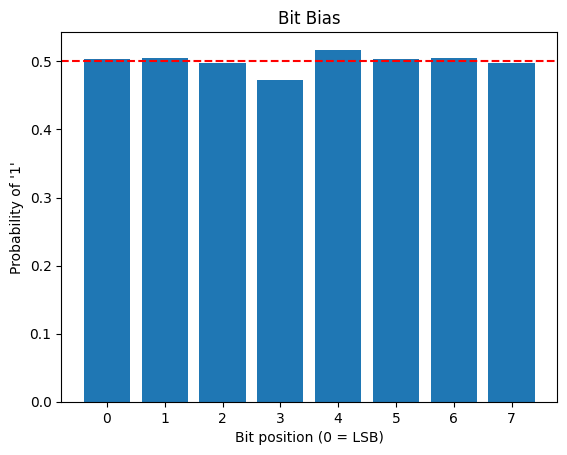


Byte distribution stats:
Min prob: 0.0236, Max prob: 0.0485, Expected = 0.0039


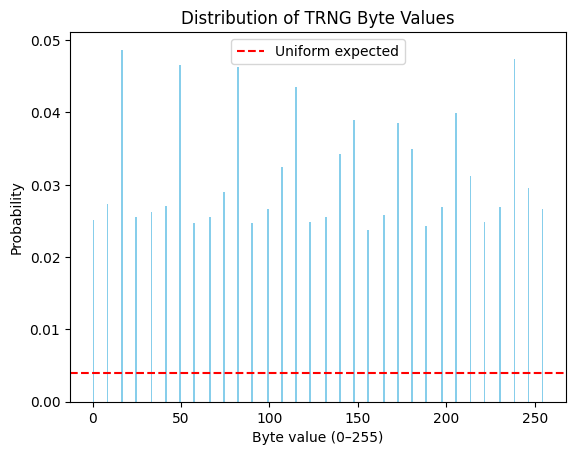

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. Collect random bytes from target =====
N = 100000   # number of random bytes to collect
rand_bytes = []

for _ in range(N):
    target.simpleserial_write('t', b'')              # request one byte
    resp = target.simpleserial_read('t', 1, timeout=2000)
    if resp:
        rand_bytes.append(resp[0])

rand_bytes = np.array(rand_bytes, dtype=np.uint8)

print(f"Collected {len(rand_bytes)} random bytes")

# ===== 2. Bit bias analysis =====
bit_counts = np.zeros(8)
for i in range(8):
    bit_counts[i] = np.sum((rand_bytes >> i) & 1)

bit_bias = bit_counts / len(rand_bytes)  # fraction of 1s per bit

print("Bit biases (probability of '1' for each bit position):")
for i, p in enumerate(bit_bias):
    print(f"Bit {i}: {p:.4f}")

plt.bar(range(8), bit_bias)
plt.axhline(0.5, color='r', linestyle='--')
plt.xlabel("Bit position (0 = LSB)")
plt.ylabel("Probability of '1'")
plt.title("Bit Bias")
plt.show()

# ===== 3. Byte value distribution =====
values, counts = np.unique(rand_bytes, return_counts=True)
probs = counts / len(rand_bytes)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(rand_bytes, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 0. Params =====
N = 20000  # number of bytes to collect (start with 20k; bump to 100k for tighter CIs)

# ===== 1. Collect random bytes from target =====
rand_bytes = np.empty(N, dtype=np.uint8)
got = 0
while got < N:
    target.simpleserial_write('t', b'')                 # ask device for 1 byte
    resp = target.simpleserial_read('t', 1, timeout=2000)
    if resp and len(resp) == 1:
        rand_bytes[got] = resp[0]
        got += 1
print(f"Collected {got} bytes")

# ===== 2. Bit bias per position (0 = LSB) + 95% CI =====
bit_counts = np.array([np.sum((rand_bytes >> i) & 1) for i in range(8)], dtype=float)
bit_bias = bit_counts / N  # P(bit=1)
# 95% CI width (normal approx around 0.5): 1.96*sqrt(p(1-p)/N) ~ 1.96*sqrt(0.25/N)
ci = 1.96 * np.sqrt(0.25 / N)

print("\nBit biases (P[1]) with 95% CI around 0.5:")
for i, p in enumerate(bit_bias):
    print(f"bit {i}: {p:.4f}   (target 0.5 ± {ci:.4f})")

plt.figure()
plt.bar(range(8), bit_bias)
plt.axhline(0.5 + ci, linestyle='--')
plt.axhline(0.5 - ci, linestyle='--')
plt.xlabel("Bit position (0 = LSB)"); plt.ylabel("P(bit=1)"); plt.title("Per-bit bias")
plt.show()

# ===== 3. Byte distribution + chi-square (goodness-of-fit to uniform) =====
counts, _ = np.histogram(rand_bytes, bins=256, range=(0,256))
E = N / 256.0
chisq = ((counts - E)**2 / E).sum()
print(f"\nChi-square statistic (df=255) = {chisq:.1f}  (smaller is better)")
# (If you have SciPy: from scipy.stats import chi2; p = 1-chi2.cdf(chisq, 255))

plt.figure()
plt.hist(rand_bytes, bins=np.arange(257)-0.5, density=True)  # bin centers on integers
plt.axhline(1/256, linestyle='--', label="Uniform expectation")
plt.xlabel("Byte value"); plt.ylabel("Probability"); plt.title("Byte distribution"); plt.legend()
plt.show()

# ===== 4. Serial correlation (bytes) =====
b0 = rand_bytes[:-1].astype(np.float64)
b1 = rand_bytes[1:].astype(np.float64)
num = np.dot(b0 - b0.mean(), b1 - b1.mean())
den = np.sqrt(((b0 - b0.mean())**2).sum() * ((b1 - b1.mean())**2).sum())
rho = num / den
print(f"\nLag-1 serial correlation (bytes): r = {rho:.4f}  (~0 is good)")

# ===== 5. Optional: bit-level runs test on LSB =====
lsb = (rand_bytes & 1).astype(np.int8)
transitions = np.count_nonzero(lsb[1:] ^ lsb[:-1])
print(f"LSB transitions: {transitions} over {N-1} steps (expected ~{(N-1)*0.5:.0f})")


In [ ]:

import math, numpy as np, time



def request_bits(nbits):
    """Send 'r<nbits>' and receive ceil(nbits/8) bytes. Returns np.uint8 array of packed bytes."""
    payload = f"{nbits}".encode()
    target.simpleserial_write(CMD_TAG, payload)
    nbytes = (nbits + 7) // 8
    data = target.simpleserial_read(CMD_TAG, nbytes)
    if data is None or len(data) != nbytes:
        raise IOError(f"Timeout/short read: wanted {nbytes}, got {None if data is None else len(data)}")
    return np.frombuffer(data, dtype=np.uint8)

def bytes_to_bits(byte_arr, nbits_wanted):
    bits = np.unpackbits(byte_arr, bitorder="big")
    return bits[:nbits_wanted].astype(np.uint8)

total_bits = NBITS_TO_COLLECT
collected = []

t0 = time.time()
remaining = total_bits
while remaining > 0:
    ask = min(CHUNK_BITS, remaining)
    b = request_bits(ask)
    bits = bytes_to_bits(b, ask)
    collected.append(bits)
    remaining -= ask

t_elapsed = time.time() - t0
bits = np.concatenate(collected)
bps = len(bits) / t_elapsed
print(f"Collected {len(bits)} bits in {t_elapsed:.2f}s -> {bps:.1f} bits/s")

# Save raw artifacts
np.save(f"/mnt/data/{SAVE_PREFIX}_bits.npy", bits)
np.savetxt(f"/mnt/data/{SAVE_PREFIX}_bits.csv", bits, fmt="%d", delimiter=",")
print("Saved:", f"/mnt/data/{SAVE_PREFIX}_bits.npy", f"/mnt/data/{SAVE_PREFIX}_bits.csv", sep="\n  ")


## 4) Quick tests & metrics

In [ ]:

import numpy as np
import math
import matplotlib.pyplot as plt

def freq_monobit(bits):
    n = bits.size
    ones = int(bits.sum())
    p_hat = ones / n
    s = abs(ones - (n - ones))
    z = s / math.sqrt(n)
    return {"n": n, "ones": ones, "p_hat": p_hat, "z": z}

def runs_test(bits):
    n = bits.size
    ones = bits.sum()
    zeros = n - ones
    if ones == 0 or zeros == 0:
        return {"n": n, "runs": 1, "p_value": 0.0, "note": "all bits equal"}
    runs = 1 + int(np.sum(bits[1:] != bits[:-1]))
    pi = ones / n
    exp_runs = 2 * n * pi * (1 - pi) + 1
    var_runs = (2 * n * pi * (1 - pi) * (2 * n * pi * (1 - pi) - 1)) / (n - 1)
    z = (runs - exp_runs) / math.sqrt(var_runs) if var_runs > 0 else float("inf")
    from math import erf, sqrt
    p_value = 2 * (1 - 0.5 * (1 + erf(abs(z)/sqrt(2))))
    return {"n": n, "runs": runs, "expected": exp_runs, "z": z, "p_value": p_value}

def autocorr(bits, max_lag=16):
    n = bits.size
    x = bits * 2 - 1
    res = {}
    for k in range(1, max_lag+1):
        a = np.dot(x[:-k], x[k:]) / (n - k)
        res[k] = float(a)
    return res

def shannon_entropy_per_bit(bits):
    if bits.size < 8:
        return float('nan'), None
    pad = (8 - bits.size % 8) % 8
    if pad:
        bits = np.concatenate([bits, np.zeros(pad, dtype=np.uint8)])
    bytes_ = np.packbits(bits, bitorder="big")
    counts = np.bincount(bytes_, minlength=256).astype(np.float64)
    probs = counts / counts.sum()
    nz = probs[probs > 0]
    H_bytes = -np.sum(nz * np.log2(nz))
    return float(H_bytes / 8.0), counts

def min_entropy_bit(bits):
    p_hat = bits.mean()
    p_max = max(p_hat, 1 - p_hat)
    Hmin = -math.log2(p_max) if p_max > 0 else 0.0
    return Hmin

freq = freq_monobit(bits)
runs = runs_test(bits)
ac = autocorr(bits, max_lag=16)
Hperbit, byte_counts = shannon_entropy_per_bit(bits)
Hmin = min_entropy_bit(bits)

print("Frequency (monobit):", freq)
print("Runs test:", runs)
print("Autocorr (first 8 lags):", {k: round(v,4) for k,v in list(ac.items())[:8]})
print(f"Shannon entropy/bit (via bytes): {Hperbit:.5f}")
print(f"Min-entropy/bit (most common bit): {Hmin:.5f}")

plt.figure()
plt.title("Byte histogram (first 64 bins) - TRNG Approach A")
plt.bar(np.arange(64), byte_counts[:64])
plt.xlabel("Byte value (0..63)")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.title("Autocorrelation vs lag - TRNG Approach A")
plt.plot(list(ac.keys()), list(ac.values()))
plt.xlabel("Lag (bits)")
plt.ylabel("Autocorr")
plt.grid(True)
plt.show()


## 5) Save a one-page text report (quick summary)

In [ ]:

report = f"""TRNG Approach A - RTC vs TCC jitter (XMEGA CW303)
Bits collected: {bits.size}

Frequency (monobit):
  ones = {freq['ones']}, p_hat = {freq['p_hat']:.6f}, z = {freq['z']:.3f}

Runs test:
  runs = {runs.get('runs')}, expected = {runs.get('expected', float('nan')):.2f},
  z = {runs.get('z', float('nan')):.3f}, p = {runs.get('p_value', float('nan')):.4f}

Entropy:
  Shannon entropy/bit (via bytes) = {Hperbit:.6f}
  Min-entropy/bit (bit MCV)       = {Hmin:.6f}

Notes:
  - This is a quick sanity battery; not a replacement for full NIST STS.
  - Duplicate this notebook for other approaches (ADC noise, RO, SRAM) and re-run.
"""

path = f"/mnt/data/{SAVE_PREFIX}_summary.txt"
with open(path, "w") as f:
    f.write(report)
print(report)
print("Saved report:", path)


## 6) Cleanup / disconnect (optional)

In [ ]:

try:
    target.dis()
except Exception:
    pass
try:
    scope.dis()
except Exception:
    pass
print("Disconnected.")
